# 02 — Feature Engineering
**Amreen**

Prototyping the feature set here. Once I'm happy with it, the logic moves to
`src/features/build_features.py` which is what the training scripts actually use.

Feature groups:
1. RUL label (regression target)
2. Binary failure label (classification target)
3. Rolling mean + std (5, 15, 30 cycle windows)
4. Degradation slope (linear trend)
5. Cumulative deviation from baseline


In [1]:
import sys, os
sys.path.insert(0, '..')
import pandas as pd, numpy as np, matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

from src.ingestion.load_data    import load_train
from src.features.build_features import (
    add_rul_labels, add_failure_label,
    add_rolling_features, add_degradation_slope,
    add_cumulative_degradation, build_features, get_feature_cols,
    FLAT_SENSORS, INFORMATIVE_SENSORS
)

In [2]:
train_raw = load_train(data_dir='../data/raw')
print(f"Raw shape: {train_raw.shape}")
train_raw.head(3)

Raw shape: (19134, 26)


,unit_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,0.0000,0.0002,100.0,518.6639,642.1547,1582.1158,1405.1217,14.6200,...,520.5652,2386.6137,8139.0524,8.3136,0.03,390.7382,2387.9831,100.0031,38.8425,23.2885
1,1,2,0.0001,-0.0006,100.0,518.6727,645.2272,1594.9686,1406.6252,14.6194,...,518.2651,2392.9401,8144.1196,8.3354,0.03,389.4029,2388.0403,99.9982,38.8437,23.4388
2,1,3,0.0000,0.0001,100.0,518.6765,643.8731,1599.3890,1412.5852,14.6198,...,519.4422,2401.2536,8120.3956,8.3231,0.03,389.2018,2388.0415,100.0006,38.9785,23.4330


## Step 1 — RUL labels

In [3]:
df = add_rul_labels(train_raw.copy())
print("RUL distribution:")
print(df['rul'].describe().round(1))

# quick sanity check: last cycle of each engine should have rul=0
last_cycles = df.groupby('unit_id').last()
assert (last_cycles['rul'] == 0).all(), "Some engines don't end at RUL=0"
print("Sanity check passed: all engines end at RUL=0")

RUL distribution:
count    19134.0
mean       127.2
std         81.2
min          0.0
25%         59.0
50%        119.0
75%        187.0
max        343.0
Name: rul, dtype: float64
Sanity check passed: all engines end at RUL=0


## Step 2 — Binary label (will fail within 30 cycles?)

In [4]:
df = add_failure_label(df, horizon=30)
pos_rate = df['will_fail'].mean()
print(f"Positive class rate: {pos_rate:.2%}  (failure imminent)")
print(f"Class distribution:\n{df['will_fail'].value_counts()}")

Positive class rate: 12.96%  (failure imminent)
Class distribution:
will_fail
0    16654
1     2480
Name: count, dtype: int64


## Step 3 — Rolling features

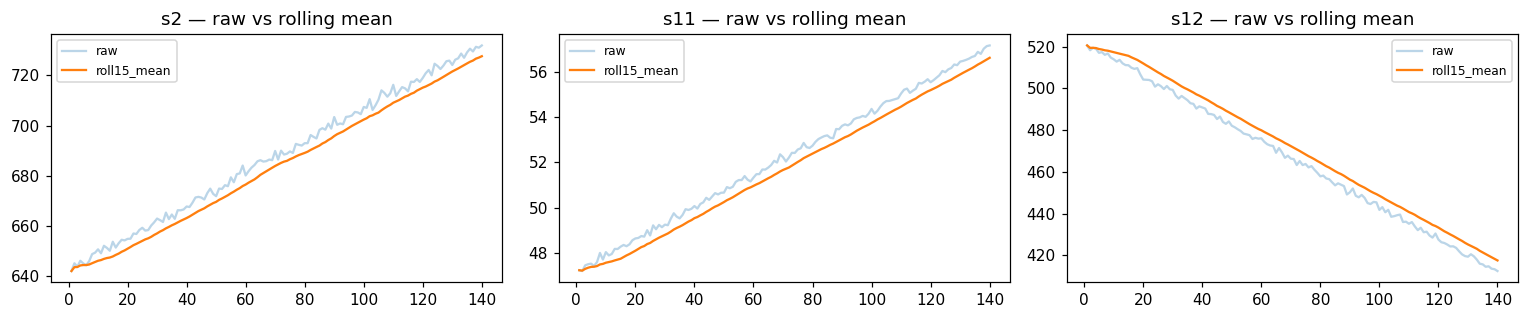

In [5]:
df = add_rolling_features(df, sensors=['s2','s11','s12'], windows=[5,15,30])

# visualise rolling mean vs raw on one engine
uid = 1
unit = df[df['unit_id']==uid].sort_values('cycle')

fig, axes = plt.subplots(1, 3, figsize=(14,3))
for ax, s in zip(axes, ['s2','s11','s12']):
    ax.plot(unit['cycle'], unit[s],           alpha=0.3, label='raw')
    ax.plot(unit['cycle'], unit[f'{s}_roll15_mean'], label='roll15_mean')
    ax.set_title(f'{s} — raw vs rolling mean')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Step 4 — Degradation slope

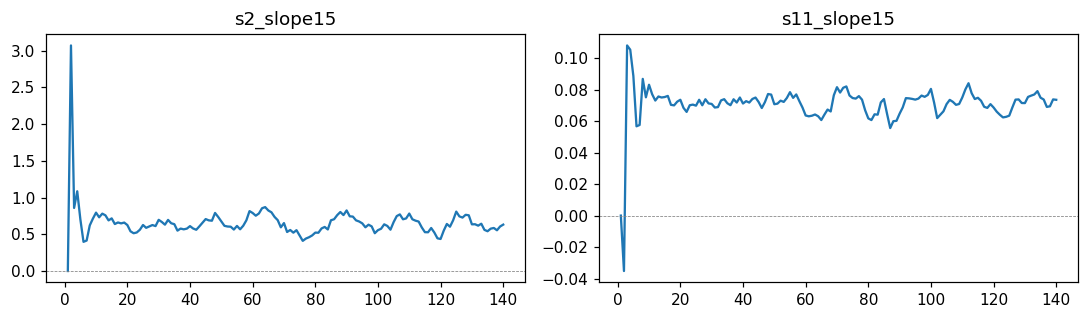

Positive slope → sensor increasing toward failure (degradation)


In [6]:
df = add_degradation_slope(df, sensors=['s2','s11'], window=15)

unit = df[df['unit_id']==1].sort_values('cycle')
fig, axes = plt.subplots(1,2, figsize=(10,3))
for ax, s in zip(axes, ['s2','s11']):
    ax.plot(unit['cycle'], unit[f'{s}_slope15'])
    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.set_title(f'{s}_slope15')
plt.tight_layout()
plt.show()
print("Positive slope → sensor increasing toward failure (degradation)")

## Step 5 — Full feature build

In [7]:
from src.features.build_features import build_features, get_feature_cols

train_feat = build_features(train_raw, is_train=True)
feat_cols  = get_feature_cols(train_feat)

print(f"Final feature count : {len(feat_cols)}")
print(f"Shape               : {train_feat.shape}")
print(f"Dropped flat sensors: {FLAT_SENSORS}")
print(f"\nSample features:\n{feat_cols[:10]}")

Final feature count : 135
Shape               : (19134, 142)
Dropped flat sensors: {'s5', 's10', 's1', 's19', 's18', 's16'}

Sample features:
['s2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13']


In [8]:
# save for use in next notebooks
train_feat.to_csv('../data/processed/train_features.csv', index=False)
print("Saved to data/processed/train_features.csv")

Saved to data/processed/train_features.csv
